# Session 5 — Supervised Learning, Deployment & Streamlit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-05-supervised-learning.ipynb)

**ML/AI & GenAI Internship** · Regression & metrics · Six classifiers & metrics · Model saving and inference · Streamlit

---

## How to use this notebook

**The longest session in the course, and the most useful.** By the end you will have trained six classifiers, saved a model to a file, and seen the code for a web app that uses it.

| # | Topic |
|---|---|
| 1 | Supervised learning: regression and classification |
| 2 | Linear Regression and its metrics |
| 3 | Classification: six algorithms and their metrics |
| 4 | Saving, loading and inference |
| 5 | Streamlit app development |

Exercises, MCQs and tasks: [Session 5 guide](../sessions/session-05-supervised-learning.md).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"
print("ready")

ready


---
# 1. Supervised learning: regression and classification

🧠 **Past exam papers with the answer key.** You study a hundred solved problems, infer the theory yourself, then sit a new paper. **The new paper is the test set.**

| | Regression | Classification |
|---|---|---|
| Answer is | A **number** | A **category** |
| Example | Salary from experience | Loan approved or rejected |
| Bad prediction | Off by ₹4,000 | Simply wrong |

**A regression prediction can be nearly right. A classification prediction is right or wrong.** That is why the two need different metrics.

In [2]:
# The TARGET COLUMN decides which family you are in.
ads   = pd.read_csv(BASE + "regression/advertising.csv")
loans = pd.read_csv(BASE + "loan_data_10k.csv")

print(f"Sales       dtype={ads['Sales'].dtype}   distinct values = {ads['Sales'].nunique()}")
print(f"loan_status dtype={loans['loan_status'].dtype}   distinct values = {loans['loan_status'].nunique()}")
print("\nMany distinct floats -> REGRESSION")
print("Two distinct values   -> CLASSIFICATION")

Sales       dtype=float64   distinct values = 121
loan_status dtype=int64   distinct values = 2

Many distinct floats -> REGRESSION
Two distinct values   -> CLASSIFICATION


### The trap: numbers that are really categories

```text
age 30 + age 30 = 60        -> meaningful  -> age is a NUMBER
pincode + pincode           -> nonsense    -> pincode is a CATEGORY
```

**If the arithmetic is meaningless, it is a category** — however it is stored.

---
# 2. Linear Regression and its metrics

```text
prediction = w1*feature1 + w2*feature2 + ... + intercept
```

🧠 **The price of a used car.** You suspect price falls ~₹40,000 per year of age and rises ~₹15,000 per unit of power. Those hunches are the **coefficients**. Linear regression works them out from data instead of guessing.

In [3]:
from sklearn.linear_model import LinearRegression

sal = pd.read_csv(BASE + "regression/salary_data.csv").dropna()
sal.columns = [c.strip().lstrip("\ufeff") for c in sal.columns]   # strip a stray BOM

m = LinearRegression().fit(sal[["Experience"]], sal["Salary"])
print(f"Salary = {m.coef_[0]:,.0f} * Experience + {m.intercept_:,.0f}")
print(f"R2 = {m.score(sal[['Experience']], sal['Salary']):.4f}")
print("\nRead it out loud: each extra year of experience is worth about")
print(f"Rs {m.coef_[0]:,.0f}, starting from a base of about Rs {m.intercept_:,.0f}.")
print("A model you can SAY IN A SENTENCE is a model you can defend in a meeting.")

Salary = 6,845 * Experience + 31,921
R2 = 0.8655

Read it out loud: each extra year of experience is worth about
Rs 6,845, starting from a base of about Rs 31,921.
A model you can SAY IN A SENTENCE is a model you can defend in a meeting.


In [4]:
# Multiple regression, and all four metrics.
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X, y = ads[["TV", "Radio", "Newspaper"]], ads["Sales"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(Xtr, ytr)
pred = model.predict(Xte)

mse = mean_squared_error(yte, pred)
print(f"MAE   {mean_absolute_error(yte, pred):7.3f}   average error size, target units")
print(f"MSE   {mse:7.3f}   SQUARED units - hard to interpret")
print(f"RMSE  {np.sqrt(mse):7.3f}   back in target units  <- QUOTE THIS ONE")
print(f"R2    {r2_score(yte, pred):7.4f}   fraction of variation explained")
print("\n'RMSE 1.7' means: typically off by about 1,700 units of sales.")
print("That sentence is what a stakeholder actually needs.")

MAE     1.275   average error size, target units
MSE     2.908   SQUARED units - hard to interpret
RMSE    1.705   back in target units  <- QUOTE THIS ONE
R2     0.9059   fraction of variation explained

'RMSE 1.7' means: typically off by about 1,700 units of sales.
That sentence is what a stakeholder actually needs.


In [5]:
# The coefficients tell a story.
for name, coef in zip(X.columns, model.coef_):
    print(f"{name:<11}{coef:+.4f}")

print("\nRadio is worth about TWICE TV per unit spent.")
print("Newspaper is worth almost nothing.")
print("That is a budget recommendation, not just a number.")
print("\n(Valid here because all three are spend in the SAME units.")
print(" Compare coefficients across different scales and you get nonsense.)")

TV         +0.0545
Radio      +0.1009
Newspaper  +0.0043

Radio is worth about TWICE TV per unit spent.
Newspaper is worth almost nothing.
That is a budget recommendation, not just a number.

(Valid here because all three are spend in the SAME units.
 Compare coefficients across different scales and you get nonsense.)


In [6]:
# Is Newspaper worth keeping at all?
X2 = ads[["TV", "Radio"]]
X2tr, X2te, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)
p2 = LinearRegression().fit(X2tr, ytr).predict(X2te)

print(f"R2 with Newspaper    : {r2_score(yte, pred):.4f}")
print(f"R2 without Newspaper : {r2_score(yte, p2):.4f}")
print("\nBarely changes -> it carries almost no information. Drop it.")
print("Fewer features = simpler, faster, easier to explain.")

R2 with Newspaper    : 0.9059
R2 without Newspaper : 0.9079

Barely changes -> it carries almost no information. Drop it.
Fewer features = simpler, faster, easier to explain.


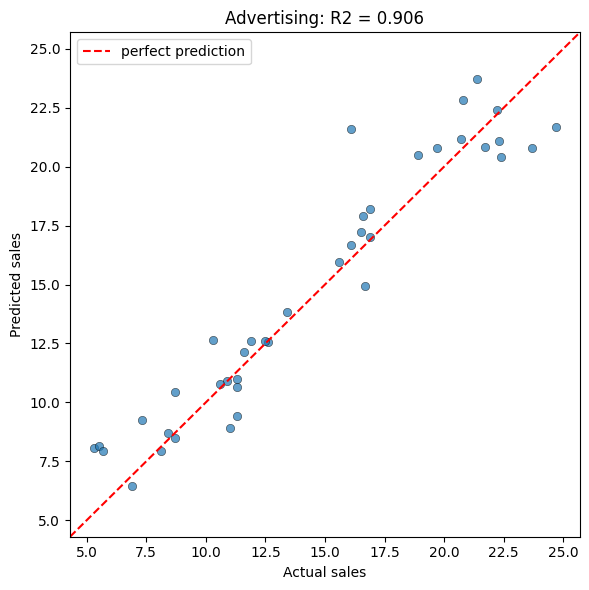

Points hugging the red line = good. A curve or a fan shape means
a straight line is the WRONG SHAPE for this data.


In [7]:
# Predicted vs actual: the plot to draw for EVERY regression.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yte, pred, alpha=0.7, edgecolor="k", linewidth=0.4)
lims = [min(yte.min(), pred.min()) - 1, max(yte.max(), pred.max()) + 1]
ax.plot(lims, lims, "r--", label="perfect prediction")
ax.set_xlabel("Actual sales"); ax.set_ylabel("Predicted sales")
ax.set_title(f"Advertising: R2 = {r2_score(yte, pred):.3f}")
ax.legend(); ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout(); plt.show()

print("Points hugging the red line = good. A curve or a fan shape means")
print("a straight line is the WRONG SHAPE for this data.")

---
# 3. Classification: six algorithms

Every one uses the **same four lines**. What changes is *how* they decide.

| Algorithm | How it decides | Needs scaling? |
|---|---|---|
| **Logistic Regression** | A weighted sum, squashed into a probability | Yes |
| **kNN** | Asks the *k* nearest neighbours to vote | **Essential** |
| **SVM** | Finds the widest boundary between classes | **Essential** |
| **Gaussian Naive Bayes** | Bayes' rule, assuming features independent | No |
| **Decision Tree** | A flowchart of yes/no questions | No |
| **Random Forest** | Hundreds of trees, voting | No |

🧠 **kNN** — asking your five nearest neighbours. **Decision Tree** — a doctor's triage flowchart. **Random Forest** — a panel of 200 doctors voting, so one odd opinion gets outvoted. **SVM** — the widest possible road between two neighbourhoods.

## First: why accuracy alone is dangerous

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

d = pd.read_csv(BASE + "classification/diabetes_prediction_dataset.csv").dropna()
for c in d.select_dtypes(include="object").columns:
    d[c] = LabelEncoder().fit_transform(d[c])

Xd, yd = d.drop(columns=["diabetes"]), d["diabetes"]
print(f"Only {yd.mean():.1%} of patients have diabetes.\n")

Xdtr, Xdte, ydtr, ydte = train_test_split(Xd, yd, test_size=.2, random_state=42, stratify=yd)
dumb = DummyClassifier(strategy="most_frequent").fit(Xdtr, ydtr)
p = dumb.predict(Xdte)

print(f"accuracy : {accuracy_score(ydte, p):.4f}   <- looks excellent")
print(f"recall   : {recall_score(ydte, p):.4f}   <- found NOBODY")
print("\nconfusion matrix:")
print(confusion_matrix(ydte, p))
print("\n1,700 diabetic patients in the test set. ZERO detected.")
print("91.5% accuracy, and the model is completely useless.")
print("ALWAYS check class balance. ALWAYS look at recall.")

Only 8.5% of patients have diabetes.

accuracy : 0.9150   <- looks excellent
recall   : 0.0000   <- found NOBODY

confusion matrix:
[[18300     0]
 [ 1700     0]]

1,700 diabetic patients in the test set. ZERO detected.
91.5% accuracy, and the model is completely useless.
ALWAYS check class balance. ALWAYS look at recall.


### Reading a confusion matrix

```text
                     predicted NO    predicted YES
   actually NO     True Negative     False Positive   <- false alarm
   actually YES    False Negative    True Positive    <- a MISS
```

| Metric | Answers |
|---|---|
| **Accuracy** | *What fraction did I get right?* |
| **Precision** | *When I say YES, how often am I right?* |
| **Recall** | *Of all real YESes, how many did I catch?* |
| **F1** | *One number balancing both* |
| **ROC-AUC** | *How well do I rank YES above NO?* |

- **Cancer screening** → maximise **recall**. A miss is fatal; a false alarm is one more test.
- **Spam filter** → maximise **precision**. Junk in the inbox is annoying; a job offer in the spam folder is a disaster.

In [9]:
# All six classifiers on the loan data, measured.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, f1_score, roc_auc_score
import time

loans_e = pd.read_csv(BASE + "loan_data_10k.csv").dropna().reset_index(drop=True)
for c in loans_e.select_dtypes(include="object").columns:
    loans_e[c] = LabelEncoder().fit_transform(loans_e[c])

X, y = loans_e.drop(columns=["loan_status"]), loans_e["loan_status"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

sc = StandardScaler()
Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)   # fit on TRAIN only

models = {
    "LogisticRegression": (LogisticRegression(max_iter=2000), True),
    "kNN (k=5)":          (KNeighborsClassifier(n_neighbors=5), True),
    "SVM (rbf)":          (SVC(kernel="rbf", probability=True, random_state=42), True),
    "GaussianNB":         (GaussianNB(), True),
    "DecisionTree":       (DecisionTreeClassifier(max_depth=6, random_state=42), False),
    "RandomForest":       (RandomForestClassifier(n_estimators=200, random_state=42), False),
}

print(f"{'model':<20}{'acc':>8}{'prec':>8}{'rec':>8}{'f1':>8}{'auc':>8}{'sec':>7}")
print("-" * 67)
fitted = {}
for name, (mo, needs_scaling) in models.items():
    a, b = (Xtr_s, Xte_s) if needs_scaling else (Xtr, Xte)
    t0 = time.time(); mo.fit(a, ytr); secs = time.time() - t0
    pr, prob = mo.predict(b), mo.predict_proba(b)[:, 1]
    fitted[name] = (mo, needs_scaling)
    print(f"{name:<20}{accuracy_score(yte,pr):>8.4f}{precision_score(yte,pr):>8.4f}"
          f"{recall_score(yte,pr):>8.4f}{f1_score(yte,pr):>8.4f}"
          f"{roc_auc_score(yte,prob):>8.4f}{secs:>7.1f}")

model                    acc    prec     rec      f1     auc    sec
-------------------------------------------------------------------
LogisticRegression    0.8650  0.8405  0.9010  0.8697  0.9401    0.0


kNN (k=5)             0.8490  0.8196  0.8950  0.8556  0.9246    0.0


SVM (rbf)             0.8780  0.8430  0.9290  0.8839  0.9479    2.9
GaussianNB            0.8245  0.7409  0.9980  0.8504  0.9316    0.0
DecisionTree          0.8545  0.8857  0.8140  0.8484  0.9467    0.0


RandomForest          0.8910  0.8710  0.9180  0.8939  0.9638    1.0


In [10]:
# Look at the two extremes: same F1-ish, COMPLETELY different personalities.
for name in ["GaussianNB", "DecisionTree"]:
    mo, scaled = fitted[name]
    pr = mo.predict(Xte_s if scaled else Xte)
    print(f"\n{name}   precision {precision_score(yte,pr):.4f}   recall {recall_score(yte,pr):.4f}")
    print(confusion_matrix(yte, pr))

print("\nGaussianNB says YES to almost everyone: it catches 99.8% of real")
print("approvals (great recall) while being wrong often (worst precision).")
print("The DecisionTree is the opposite: trustworthy when it says yes,")
print("but it misses the most.")
print("\nThis is why you NEVER report a single number.")


GaussianNB   precision 0.7409   recall 0.9980
[[651 349]
 [  2 998]]

DecisionTree   precision 0.8857   recall 0.8140
[[895 105]
 [186 814]]

GaussianNB says YES to almost everyone: it catches 99.8% of real
approvals (great recall) while being wrong often (worst precision).
The DecisionTree is the opposite: trustworthy when it says yes,
but it misses the most.

This is why you NEVER report a single number.


In [11]:
# Scaling proof: kNN measures distance, so unscaled columns wreck it.
kn_raw = KNeighborsClassifier().fit(Xtr, ytr)
kn_sc  = KNeighborsClassifier().fit(Xtr_s, ytr)
dt_raw = DecisionTreeClassifier(max_depth=6, random_state=42).fit(Xtr, ytr)
dt_sc  = DecisionTreeClassifier(max_depth=6, random_state=42).fit(Xtr_s, ytr)

print(f"{'':<16}{'unscaled':>10}{'scaled':>10}")
print(f"{'kNN':<16}{kn_raw.score(Xte, yte):>10.4f}{kn_sc.score(Xte_s, yte):>10.4f}")
print(f"{'DecisionTree':<16}{dt_raw.score(Xte, yte):>10.4f}{dt_sc.score(Xte_s, yte):>10.4f}")
print("\nkNN improves a lot: unscaled, person_income (tens of thousands)")
print("drowns out every other column in the distance calculation.")
print("The tree barely moves. It splits ONE column at a time, so the")
print("relative scale of the columns is irrelevant to it. The last decimal")
print("still wiggles because scaling shifts the split thresholds slightly -")
print("that is floating-point tie-breaking, not learning.")

                  unscaled    scaled
kNN                 0.7340    0.8490
DecisionTree        0.8545    0.8550

kNN improves a lot: unscaled, person_income (tens of thousands)
drowns out every other column in the distance calculation.
The tree barely moves. It splits ONE column at a time, so the
relative scale of the columns is irrelevant to it. The last decimal
still wiggles because scaling shifts the split thresholds slightly -
that is floating-point tie-breaking, not learning.


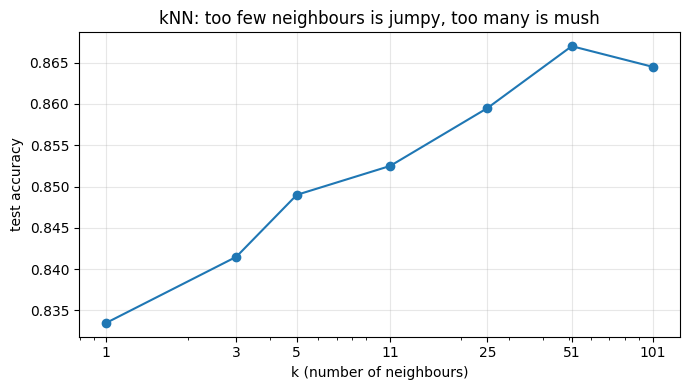

k=1     0.8335
k=3     0.8415
k=5     0.8490
k=11    0.8525
k=25    0.8595
k=51    0.8670
k=101   0.8645

k=1 memorises single points. Very large k averages everything away.
The sweet spot is in the middle - and you FIND it, you do not guess it.


In [12]:
# Choosing k for kNN.
ks = [1, 3, 5, 11, 25, 51, 101]
scores = [KNeighborsClassifier(n_neighbors=k).fit(Xtr_s, ytr).score(Xte_s, yte) for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, scores, "o-")
ax.set_xscale("log"); ax.set_xticks(ks); ax.set_xticklabels(ks)
ax.set_xlabel("k (number of neighbours)"); ax.set_ylabel("test accuracy")
ax.set_title("kNN: too few neighbours is jumpy, too many is mush")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

for k, s in zip(ks, scores):
    print(f"k={k:<5} {s:.4f}")
print("\nk=1 memorises single points. Very large k averages everything away.")
print("The sweet spot is in the middle - and you FIND it, you do not guess it.")

In [13]:
# The Decision Tree, in plain English. You can hand this to a bank manager.
from sklearn.tree import export_text

tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xtr, ytr)
print(export_text(tree, feature_names=list(X.columns), max_depth=3))
print("No other model on the list gives you this.")

|--- previous_loan_defaults_on_file <= 0.50
|   |--- loan_percent_income <= 0.23
|   |   |--- loan_int_rate <= 13.98
|   |   |   |--- class: 0
|   |   |--- loan_int_rate >  13.98
|   |   |   |--- class: 1
|   |--- loan_percent_income >  0.23
|   |   |--- person_home_ownership <= 2.50
|   |   |   |--- class: 1
|   |   |--- person_home_ownership >  2.50
|   |   |   |--- class: 1
|--- previous_loan_defaults_on_file >  0.50
|   |--- class: 0

No other model on the list gives you this.


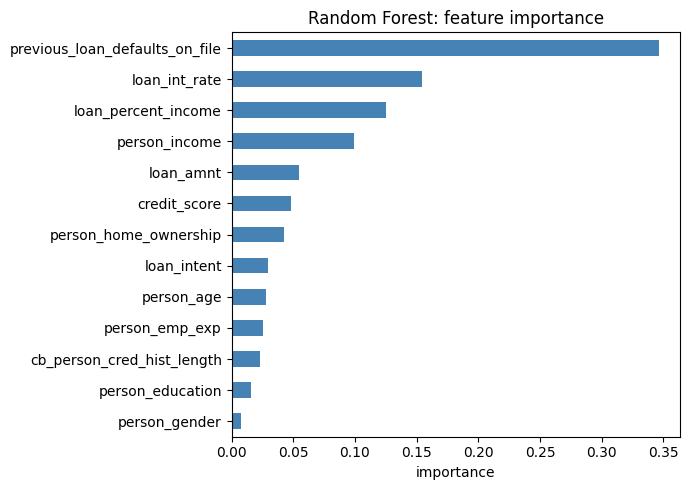

previous_loan_defaults_on_file    0.3461
loan_int_rate                     0.1543
loan_percent_income               0.1252
person_income                     0.0991
loan_amnt                         0.0548
dtype: float64


In [14]:
# Which features does the forest actually use?
rf = fitted["RandomForest"][0]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest: feature importance")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

print(imp.sort_values(ascending=False).head(5).round(4))

---
# 4. Saving, loading and inference

🧠 **A cooked meal versus the recipe.** Training is cooking — slow, done once. Saving is putting it in the fridge. Inference is reheating a portion when someone is hungry. **You do not re-cook the whole meal for every guest.**

> ⚠️ **The number one deployment bug:** saving the model but not the scaler. The app then feeds raw values into a model expecting scaled ones and is **quietly wrong**. The fix is to save a `Pipeline`.

In [15]:
# A Pipeline puts the preprocessing INSIDE the saved object.
from sklearn.pipeline import Pipeline
import joblib, os, tempfile

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=2000)),
])
pipe.fit(Xdtr, ydtr)      # the scaler fits on TRAIN only - leak-proof by design

path = os.path.join(tempfile.gettempdir(), "diabetes_pipeline.joblib")
joblib.dump(pipe, path)
print("saved:", round(os.path.getsize(path) / 1024, 1), "KB")

fresh = joblib.load(path)          # imagine this is a completely different program
print(f"score before save : {pipe.score(Xdte, ydte):.4f}")
print(f"score after load  : {fresh.score(Xdte, ydte):.4f}")
print("\nIdentical. That is the whole point.")

saved: 1.9 KB
score before save : 0.9603
score after load  : 0.9603

Identical. That is the whole point.


In [16]:
# Inference on ONE new person.
new_patient = pd.DataFrame([{
    "gender": 1, "age": 54.0, "hypertension": 1, "heart_disease": 0,
    "smoking_history": 4, "bmi": 31.2, "HbA1c_level": 6.8,
    "blood_glucose_level": 160,
}])

print("prediction :", fresh.predict(new_patient)[0])
print("probability:", round(fresh.predict_proba(new_patient)[0][1], 4))
print("\nColumn NAMES and ORDER must match training exactly.")
print("Build the row as a DataFrame, never as a bare list.")

prediction : 1
probability: 0.5996

Column NAMES and ORDER must match training exactly.
Build the row as a DataFrame, never as a bare list.


In [17]:
# Save the metadata too - in six months you will not remember the column order.
import sklearn

bundle = {
    "pipeline": pipe,
    "features": list(Xd.columns),
    "target": "diabetes",
    "test_score": float(pipe.score(Xdte, ydte)),
    "sklearn_version": sklearn.__version__,
}
bpath = os.path.join(tempfile.gettempdir(), "diabetes_bundle.joblib")
joblib.dump(bundle, bpath)

b = joblib.load(bpath)
print("features:", b["features"])
print(f"trained with sklearn {b['sklearn_version']}, score {b['test_score']:.4f}")

features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
trained with sklearn 1.9.0, score 0.9603


In [18]:
# How big do model files get?
rf_path = os.path.join(tempfile.gettempdir(), "rf.joblib")
joblib.dump(rf, rf_path)

print(f"logistic pipeline : {os.path.getsize(path)/1024:>10,.1f} KB")
print(f"random forest     : {os.path.getsize(rf_path)/1024:>10,.0f} KB")
print("\nThe forest stores 200 whole trees.")
print("This is why model files belong in .gitignore: large binaries that")
print("change ENTIRELY on every retrain. Commit the training script instead.")
print("\nAnd: a .joblib file is EXECUTABLE CODE. Only load ones you produced.")

logistic pipeline :        1.9 KB
random forest     :     22,344 KB

The forest stores 200 whole trees.
This is why model files belong in .gitignore: large binaries that
change ENTIRELY on every retrain. Commit the training script instead.

And: a .joblib file is EXECUTABLE CODE. Only load ones you produced.


---
# 5. Streamlit App Development

🧠 **Streamlit reruns your whole script top to bottom on every interaction.** Picture a whiteboard wiped and rewritten each time someone moves a slider. That single fact explains almost everything about how it behaves — including why you must cache the model.

Streamlit apps are `.py` files run from a terminal, not notebook cells — so the code below is shown, not executed here.

### The minimum app

```python
# app.py
import streamlit as st
import pandas as pd
import joblib

st.title("Diabetes Risk Checker")

@st.cache_resource            # <- load ONCE, not on every click
def load_model():
    return joblib.load("diabetes_pipeline.joblib")

model = load_model()

age     = st.slider("Age", 1, 100, 45)
bmi     = st.slider("BMI", 10.0, 60.0, 27.0)
hba1c   = st.slider("HbA1c level", 3.0, 9.0, 5.7)
glucose = st.slider("Blood glucose", 70, 300, 140)
hypertension = st.checkbox("Hypertension")

if st.button("Predict"):
    row = pd.DataFrame([{
        "gender": 1, "age": age, "hypertension": int(hypertension),
        "heart_disease": 0, "smoking_history": 4, "bmi": bmi,
        "HbA1c_level": hba1c, "blood_glucose_level": glucose,
    }])
    prob = model.predict_proba(row)[0][1]
    st.metric("Risk", f"{prob:.1%}")
    st.warning("Elevated risk") if prob > 0.5 else st.success("Low risk")
    st.caption("Educational demo only. Not medical advice.")
```

Run it:

```bash
streamlit run app.py
```

### The three rules that fix most Streamlit bugs

1. **`@st.cache_resource`** on anything you *load* — models, connections. Without it a 22MB forest reloads on every keypress.
2. **`@st.cache_data`** on anything you *compute* — loaded CSVs, aggregations.
3. **`st.session_state`** for anything that must survive a rerun.

```python
if "history" not in st.session_state:
    st.session_state.history = []      # runs once, not on every rerun

st.session_state.history.append(prob)
st.line_chart(st.session_state.history)
```

### Batch scoring from an upload

```python
uploaded = st.file_uploader("Upload rows to score", type="csv")
if uploaded:
    new = pd.read_csv(uploaded)
    new["risk"] = model.predict_proba(new)[:, 1]
    st.dataframe(new.sort_values("risk", ascending=False))
    st.download_button("Download results", new.to_csv(index=False), "scored.csv")
```

> ⚠️ **Never hard-code an API key.** Put it in `.streamlit/secrets.toml`, read `st.secrets["KEY"]`, and gitignore the file. See [setup-guide.md](../setup-guide.md).

---
# ✅ Before you move on

- [ ] Telling regression from classification from the target column alone
- [ ] Reading a Linear Regression's coefficients out loud as a sentence
- [ ] Knowing why RMSE is the metric to quote, and why R² = 1.0 is suspicious
- [ ] Comparing all six classifiers on five metrics
- [ ] kNN and SVM need scaling; trees do not
- [ ] Reading a confusion matrix, and why 91.5% accuracy can be worthless
- [ ] Naming a problem needing high recall and one needing high precision
- [ ] Saving a **pipeline** and loading it in a separate program
- [ ] Building a Streamlit app that makes live predictions

**Exercises, MCQs and tasks:** [Session 5 guide](../sessions/session-05-supervised-learning.md)

| | |
|---|---|
| **Previous** | [Session 4 — Introduction to ML & AI](../sessions/session-04-intro-ml-ai.md) |
| **Streamlit** | [Simple app](../tutorials/apps/streamlit-app-simple.md) · [Advanced](../tutorials/apps/streamlit-app-advanced.md) · [Loan app](../tutorials/apps/loan-app.md) |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) |